# __Preprocesamiento de los datos__

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

## Cargar datos

In [19]:
df1 = pd.read_excel('../data/Afluencia_2021.xlsx')
df2 = pd.read_excel('../data/Afluencia_2022.xlsx')
df3 = pd.read_excel('../data/Afluencia_2023.xlsx')
df4 = pd.read_excel('../data/Afluencia_2024.xlsx')
df5 = pd.read_excel('../data/Afluencia_2025.xlsx')

df_total = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)
df_total

,Fecha,Linea,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,10:00:00,11:00:00,...,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00,Total general (Número de pasajeros)
0,2021-01-01 00:00:00,LÍNEA A,NaN,3487.0,3405.0,2011.0,1148.0,974.0,888.0,1011.0,...,1833.0,2900.0,3269.0,3314.0,2273.0,1329.0,12.0,NaN,NaN,31911
1,2021-01-01 00:00:00,LÍNEA B,NaN,532.0,438.0,267.0,164.0,145.0,135.0,142.0,...,212.0,321.0,421.0,432.0,215.0,157.0,NaN,NaN,NaN,4050
2,2021-01-01 00:00:00,LÍNEA K,NaN,NaN,NaN,NaN,40.0,131.0,104.0,156.0,...,167.0,258.0,189.0,122.0,103.0,38.0,NaN,NaN,NaN,1714
3,2021-01-01 00:00:00,LÍNEA J,NaN,NaN,NaN,NaN,1.0,77.0,74.0,92.0,...,146.0,179.0,132.0,135.0,69.0,42.0,3.0,NaN,NaN,1256
4,2021-01-01 00:00:00,LÍNEA 1,NaN,614.0,590.0,355.0,240.0,217.0,198.0,231.0,...,394.0,579.0,624.0,574.0,399.0,231.0,17.0,NaN,NaN,6104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20220,2025-09-30 00:00:00,LÍNEA K,2430.0,2828.0,2543.0,2160.0,1852.0,1345.0,1111.0,1204.0,...,753.0,1026.0,860.0,624.0,525.0,559.0,270.0,100.0,NaN,23385
20221,2025-09-30 00:00:00,LÍNEA M,381.0,1056.0,931.0,711.0,452.0,364.0,303.0,352.0,...,494.0,659.0,659.0,1178.0,891.0,526.0,402.0,306.0,74.0,10881
20222,2025-09-30 00:00:00,LÍNEA O,265.0,1592.0,1723.0,1820.0,1195.0,1190.0,850.0,1091.0,...,1145.0,1529.0,1810.0,1231.0,1119.0,904.0,825.0,310.0,14.0,21785
20223,2025-09-30 00:00:00,LÍNEA P,1315.0,3172.0,2793.0,2575.0,1621.0,1065.0,735.0,987.0,...,708.0,874.0,979.0,625.0,482.0,579.0,386.0,157.0,3.0,21684


In [20]:
df_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20225 entries, 0 to 20224
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Fecha                                20225 non-null  object 
 1   Linea                                20225 non-null  object 
 2   04:00:00                             17109 non-null  float64
 3   05:00:00                             17186 non-null  float64
 4   06:00:00                             17190 non-null  float64
 5   07:00:00                             17204 non-null  float64
 6   08:00:00                             19301 non-null  float64
 7   09:00:00                             20177 non-null  float64
 8   10:00:00                             20169 non-null  float64
 9   11:00:00                             20160 non-null  float64
 10  12:00:00                             20166 non-null  float64
 11  13:00:00                    

## Limpiar datos

In [21]:
df_total.head(5)

,Fecha,Linea,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,10:00:00,11:00:00,...,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00,Total general (Número de pasajeros)
0,2021-01-01 00:00:00,LÍNEA A,NaN,3487.0,3405.0,2011.0,1148.0,974.0,888.0,1011.0,...,1833.0,2900.0,3269.0,3314.0,2273.0,1329.0,12.0,NaN,NaN,31911
1,2021-01-01 00:00:00,LÍNEA B,NaN,532.0,438.0,267.0,164.0,145.0,135.0,142.0,...,212.0,321.0,421.0,432.0,215.0,157.0,NaN,NaN,NaN,4050
2,2021-01-01 00:00:00,LÍNEA K,NaN,NaN,NaN,NaN,40.0,131.0,104.0,156.0,...,167.0,258.0,189.0,122.0,103.0,38.0,NaN,NaN,NaN,1714
3,2021-01-01 00:00:00,LÍNEA J,NaN,NaN,NaN,NaN,1.0,77.0,74.0,92.0,...,146.0,179.0,132.0,135.0,69.0,42.0,3.0,NaN,NaN,1256
4,2021-01-01 00:00:00,LÍNEA 1,NaN,614.0,590.0,355.0,240.0,217.0,198.0,231.0,...,394.0,579.0,624.0,574.0,399.0,231.0,17.0,NaN,NaN,6104


In [22]:
# convertir valores nulos en cero
df_total.fillna(0, inplace=True)
df_total.head(5)

,Fecha,Linea,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,10:00:00,11:00:00,...,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00,Total general (Número de pasajeros)
0,2021-01-01 00:00:00,LÍNEA A,0.0,3487.0,3405.0,2011.0,1148.0,974.0,888.0,1011.0,...,1833.0,2900.0,3269.0,3314.0,2273.0,1329.0,12.0,0.0,0.0,31911
1,2021-01-01 00:00:00,LÍNEA B,0.0,532.0,438.0,267.0,164.0,145.0,135.0,142.0,...,212.0,321.0,421.0,432.0,215.0,157.0,0.0,0.0,0.0,4050
2,2021-01-01 00:00:00,LÍNEA K,0.0,0.0,0.0,0.0,40.0,131.0,104.0,156.0,...,167.0,258.0,189.0,122.0,103.0,38.0,0.0,0.0,0.0,1714
3,2021-01-01 00:00:00,LÍNEA J,0.0,0.0,0.0,0.0,1.0,77.0,74.0,92.0,...,146.0,179.0,132.0,135.0,69.0,42.0,3.0,0.0,0.0,1256
4,2021-01-01 00:00:00,LÍNEA 1,0.0,614.0,590.0,355.0,240.0,217.0,198.0,231.0,...,394.0,579.0,624.0,574.0,399.0,231.0,17.0,0.0,0.0,6104


In [23]:
# convertir campos float a enteros
cols_float = df_total.select_dtypes(include='float').columns
df_total[cols_float] = df_total[cols_float].astype(int)
df_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20225 entries, 0 to 20224
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   Fecha                                20225 non-null  object
 1   Linea                                20225 non-null  object
 2   04:00:00                             20225 non-null  int64 
 3   05:00:00                             20225 non-null  int64 
 4   06:00:00                             20225 non-null  int64 
 5   07:00:00                             20225 non-null  int64 
 6   08:00:00                             20225 non-null  int64 
 7   09:00:00                             20225 non-null  int64 
 8   10:00:00                             20225 non-null  int64 
 9   11:00:00                             20225 non-null  int64 
 10  12:00:00                             20225 non-null  int64 
 11  13:00:00                             2022

In [24]:
# convertir campo Fecha a datetime
df_total['Fecha'] = pd.to_datetime(df_total['Fecha'], dayfirst=True)
df_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20225 entries, 0 to 20224
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Fecha                                20225 non-null  datetime64[ns]
 1   Linea                                20225 non-null  object        
 2   04:00:00                             20225 non-null  int64         
 3   05:00:00                             20225 non-null  int64         
 4   06:00:00                             20225 non-null  int64         
 5   07:00:00                             20225 non-null  int64         
 6   08:00:00                             20225 non-null  int64         
 7   09:00:00                             20225 non-null  int64         
 8   10:00:00                             20225 non-null  int64         
 9   11:00:00                             20225 non-null  int64         
 10  12:00:00  

In [25]:
df_total.head(5)

,Fecha,Linea,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,10:00:00,11:00:00,...,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00,Total general (Número de pasajeros)
0,2021-01-01,LÍNEA A,0,3487,3405,2011,1148,974,888,1011,...,1833,2900,3269,3314,2273,1329,12,0,0,31911
1,2021-01-01,LÍNEA B,0,532,438,267,164,145,135,142,...,212,321,421,432,215,157,0,0,0,4050
2,2021-01-01,LÍNEA K,0,0,0,0,40,131,104,156,...,167,258,189,122,103,38,0,0,0,1714
3,2021-01-01,LÍNEA J,0,0,0,0,1,77,74,92,...,146,179,132,135,69,42,3,0,0,1256
4,2021-01-01,LÍNEA 1,0,614,590,355,240,217,198,231,...,394,579,624,574,399,231,17,0,0,6104


In [26]:
# quitar la palabra Linea del campo Linea
df_total['Linea'] = df_total['Linea'].str.replace('LÍNEA', '', regex=False)
df_total['Linea'] = df_total['Linea'].str.strip()
df_total.sample(10)

,Fecha,Linea,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,10:00:00,11:00:00,...,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00,Total general (Número de pasajeros)
1140,2021-04-16,O,83,471,602,393,215,162,126,129,...,267,417,541,322,193,125,115,30,1,4678
7953,2022-11-23,B,3191,7453,8690,8586,5750,4538,4063,3909,...,5056,7286,10648,7583,4193,3536,2494,1151,12,101401
9586,2023-04-09,L,0,0,0,0,82,273,375,531,...,530,690,390,2,0,0,0,0,0,4371
3268,2021-10-20,B,2645,7017,8626,7185,4264,3678,3413,3363,...,4329,6393,9315,6956,3711,2654,2019,942,4,87599
12674,2023-12-28,J,931,1785,1892,1669,1360,1061,916,841,...,650,685,610,624,486,238,126,84,0,16312
1165,2021-04-19,1,2357,6001,6782,5822,4153,3322,2880,2759,...,3973,5558,6775,5824,3902,1834,963,516,8,72584
17682,2025-02-26,T-A,1500,4935,5201,4992,3000,2646,2331,2740,...,3476,4848,5701,5393,3204,2523,2031,1261,52,64860
280,2021-01-27,1,2054,5547,6651,5860,3944,3247,2766,2659,...,3811,5367,7117,5741,3444,2285,1657,899,24,72330
10127,2023-05-25,B,3316,8120,9371,8339,5077,4603,3935,4248,...,5125,7414,10603,7433,4369,3290,2214,1187,0,102941
13413,2024-03-01,1,2971,8713,10786,9789,6387,5609,4650,5209,...,6597,8882,10192,7567,4995,3639,2824,1711,80,116826


In [27]:
# cambiar nombre de la variable 'Total general (Número de pasajeros)'
df_total = df_total.rename(columns={'Total general (Número de pasajeros)':'Total pasajeros'})
df_total.sample()

,Fecha,Linea,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,10:00:00,11:00:00,...,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00,Total pasajeros
13841,2024-04-06,1,2138,5116,6263,7104,4727,4453,4081,4776,...,4828,4993,4459,4048,3355,2574,2325,1263,63,85325


In [28]:
df_total.head()

,Fecha,Linea,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,10:00:00,11:00:00,...,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00,Total pasajeros
0,2021-01-01,A,0,3487,3405,2011,1148,974,888,1011,...,1833,2900,3269,3314,2273,1329,12,0,0,31911
1,2021-01-01,B,0,532,438,267,164,145,135,142,...,212,321,421,432,215,157,0,0,0,4050
2,2021-01-01,K,0,0,0,0,40,131,104,156,...,167,258,189,122,103,38,0,0,0,1714
3,2021-01-01,J,0,0,0,0,1,77,74,92,...,146,179,132,135,69,42,3,0,0,1256
4,2021-01-01,1,0,614,590,355,240,217,198,231,...,394,579,624,574,399,231,17,0,0,6104


## Features ingening

In [29]:
# crear un campo que almacene el respectivo ano de cada fecha
df_total['Year'] = df_total['Fecha'].dt.year
df_total.head()

,Fecha,Linea,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,10:00:00,11:00:00,...,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00,Total pasajeros,Year
0,2021-01-01,A,0,3487,3405,2011,1148,974,888,1011,...,2900,3269,3314,2273,1329,12,0,0,31911,2021
1,2021-01-01,B,0,532,438,267,164,145,135,142,...,321,421,432,215,157,0,0,0,4050,2021
2,2021-01-01,K,0,0,0,0,40,131,104,156,...,258,189,122,103,38,0,0,0,1714,2021
3,2021-01-01,J,0,0,0,0,1,77,74,92,...,179,132,135,69,42,3,0,0,1256,2021
4,2021-01-01,1,0,614,590,355,240,217,198,231,...,579,624,574,399,231,17,0,0,6104,2021


In [30]:
# crear un campo que almacene los dias de la semana
df_total['Dia'] = df_total['Fecha'].dt.day_name()
df_total.head()

,Fecha,Linea,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,10:00:00,11:00:00,...,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00,Total pasajeros,Year,Dia
0,2021-01-01,A,0,3487,3405,2011,1148,974,888,1011,...,3269,3314,2273,1329,12,0,0,31911,2021,Friday
1,2021-01-01,B,0,532,438,267,164,145,135,142,...,421,432,215,157,0,0,0,4050,2021,Friday
2,2021-01-01,K,0,0,0,0,40,131,104,156,...,189,122,103,38,0,0,0,1714,2021,Friday
3,2021-01-01,J,0,0,0,0,1,77,74,92,...,132,135,69,42,3,0,0,1256,2021,Friday
4,2021-01-01,1,0,614,590,355,240,217,198,231,...,624,574,399,231,17,0,0,6104,2021,Friday


## Analisis

In [31]:
horas = [c for c in df_total.columns if c not in ("Fecha", "Linea", "Year", "Total pasajeros")]
lineas = sorted(df_total["Linea"].unique())
años = sorted(df_total["Year"].unique())

In [32]:
df_long = df_total.melt(
    id_vars=["Fecha", "Linea", "Year"],
    value_vars=horas,
    var_name="Hora",
    value_name="Pasajeros"
)
promedio = (
    df_long
    .groupby(["Year", "Linea", "Hora"])["Pasajeros"]
    .mean()
    .reset_index()
)
promedio["Hora_idx"] = pd.Categorical(promedio["Hora"], categories=horas, ordered=True)
promedio = promedio.sort_values(["Year", "Linea", "Hora_idx"])

TypeError: agg function failed [how->mean,dtype->object]

In [ ]:
promedio

,Year,Linea,Hora,Pasajeros,Hora_idx
0,2021,1,04:00:00,1919.353425,04:00:00
1,2021,1,05:00:00,5154.684932,05:00:00
2,2021,1,06:00:00,6349.567123,06:00:00
3,2021,1,07:00:00,5771.205479,07:00:00
4,2021,1,08:00:00,3931.764384,08:00:00
...,...,...,...,...,...
1255,2025,T-A,20:00:00,2051.644689,20:00:00
1256,2025,T-A,21:00:00,1638.890110,21:00:00
1257,2025,T-A,22:00:00,1010.791209,22:00:00
1258,2025,T-A,23:00:00,52.274725,23:00:00


ValueError: operands could not be broadcast together with shapes (20,) (21,) 

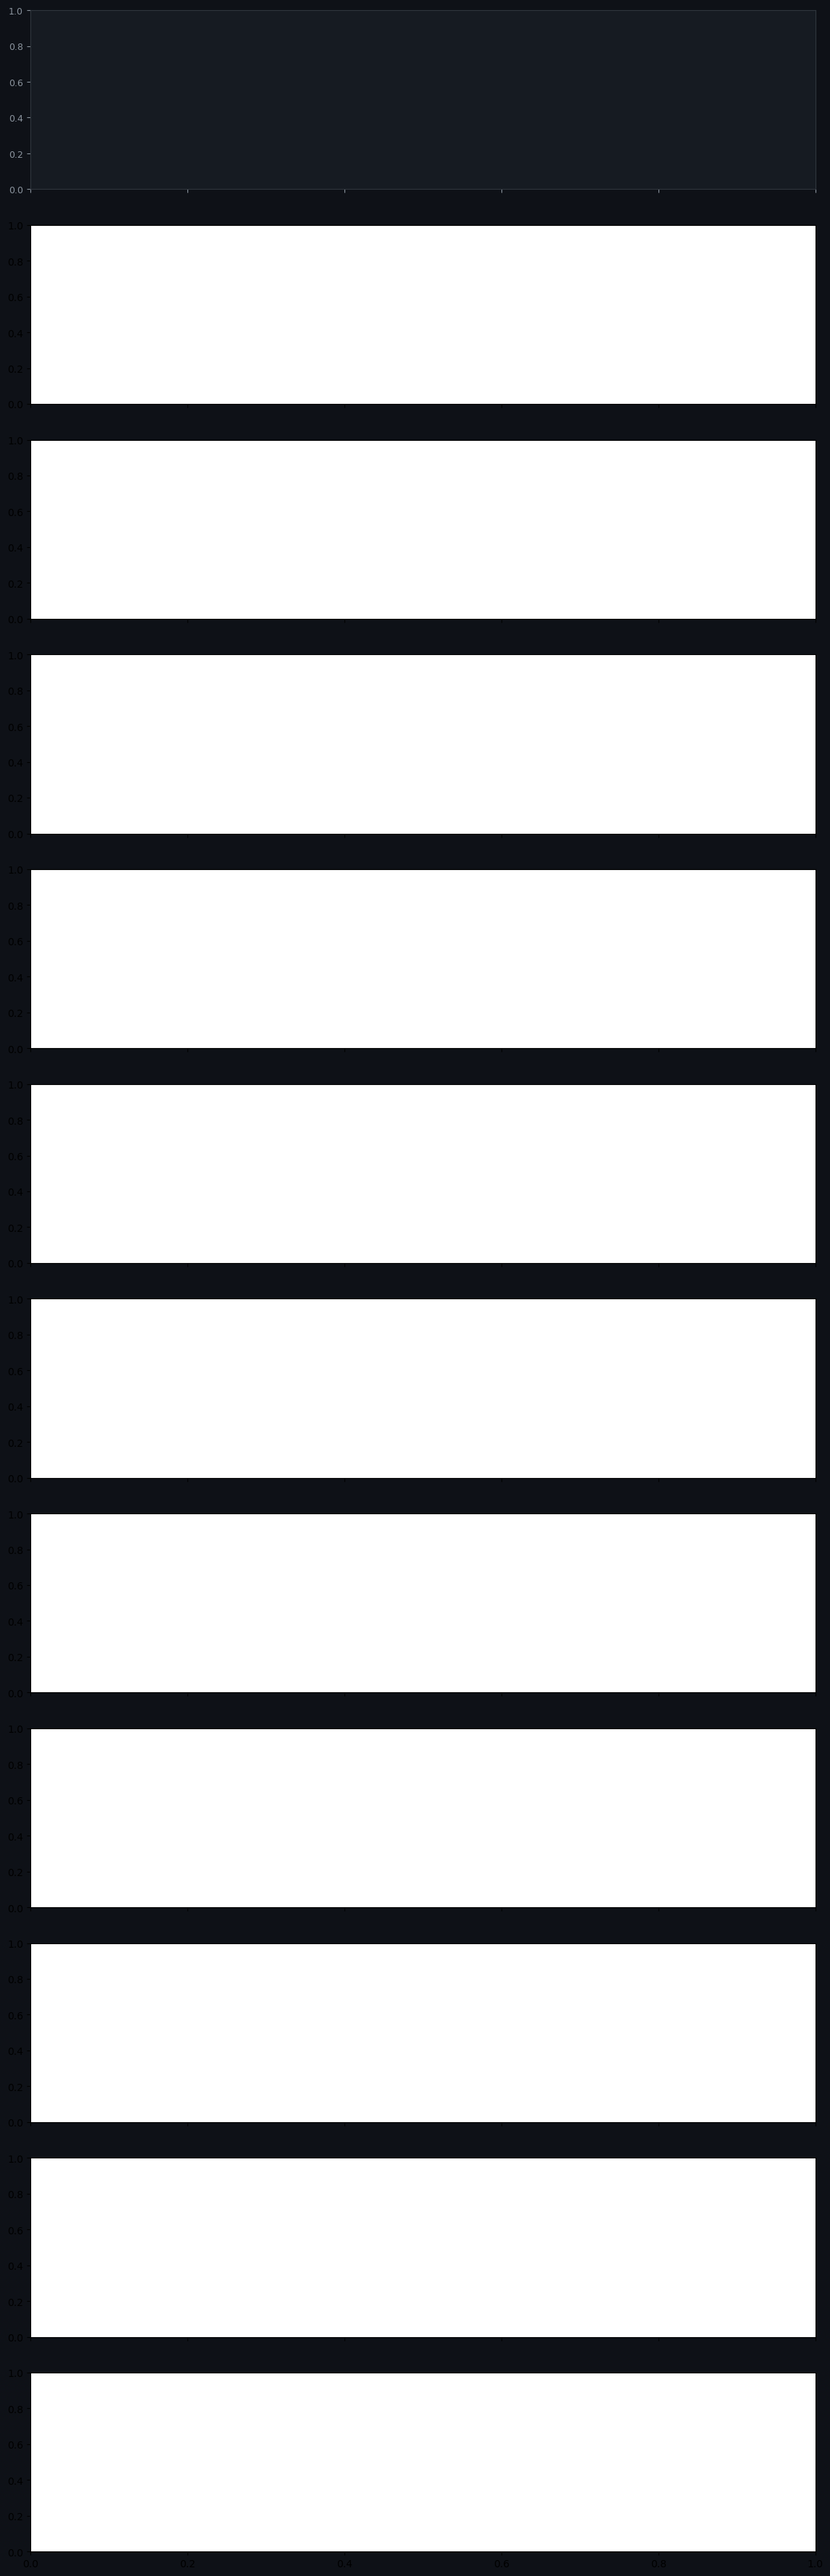

In [ ]:
PALETA = {
    2021: "#378ADD",
    2022: "#1D9E75",
    2023: "#BA7517",
    2024: "#7F77DD",
    2025: "#D85A30",
}
 
horas = [f"{h:02d}:00:00" for h in range(4, 24)]
HORA_LABELS = [h[:5] for h in horas]

n_lineas = len(lineas)
fig, axes = plt.subplots(
    n_lineas, 1,
    figsize=(14, 3.8 * n_lineas),
    sharex=True,
    facecolor="#0e1117"
)
if n_lineas == 1:
    axes = [axes]
 
fig.patch.set_facecolor("#0e1117")
 
for ax, linea in zip(axes, lineas):
    ax.set_facecolor("#161b22")
    ax.spines[:].set_color("#30363d")
    ax.tick_params(colors="#8b949e", labelsize=9)
    ax.yaxis.label.set_color("#c9d1d9")
    ax.xaxis.label.set_color("#c9d1d9")
 
    datos_linea = promedio[promedio["Linea"] == linea].copy()
    y_max_global = 0
 
    for año in años:
        datos_año = datos_linea[datos_linea["Year"] == año].copy()
        if datos_año.empty:
            continue
        y = datos_año["Pasajeros"].values
        x = np.arange(len(horas))
        color = PALETA[año]
        ax.fill_between(x, y, alpha=0.18, color=color)
        ax.plot(x, y, color=color, linewidth=1.8, label=str(año))
        y_max_global = max(y_max_global, y.max())
 
    # Marcar hora pico del promedio total
    promedio_total = datos_linea.groupby("Hora_idx")["Pasajeros"].mean().values
    idx_pico = np.argmax(promedio_total)
    ax.axvline(idx_pico, color="#f0f0f0", linewidth=0.8, linestyle="--", alpha=0.4)
    ax.annotate(
        f"Pico: {HORA_LABELS[idx_pico]}",
        xy=(idx_pico, y_max_global * 0.95),
        xytext=(idx_pico + 0.4, y_max_global * 0.95),
        fontsize=8, color="#f0f0f0", alpha=0.7,
        va="top"
    )
 
    ax.set_ylabel("Promedio pasajeros", fontsize=9, color="#8b949e")
    ax.set_title(f"Línea {linea}", fontsize=12, fontweight="bold",
                 color="#e6edf3", loc="left", pad=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda v, _: f"{int(v):,}".replace(",", ".")
    ))
    ax.set_ylim(0, y_max_global * 1.12)
    ax.grid(axis="y", color="#30363d", linewidth=0.6, linestyle=":")
    ax.grid(axis="x", color="#30363d", linewidth=0.4, linestyle=":")
 
    # Leyenda dentro del panel
    leg = ax.legend(
        title="Año", title_fontsize=8,
        fontsize=8, loc="upper right",
        framealpha=0.3, frameon=True,
        labelcolor="#c9d1d9",
        facecolor="#161b22", edgecolor="#30363d"
    )
    leg.get_title().set_color("#8b949e")
 
# Eje X compartido
axes[-1].set_xticks(np.arange(len(horas)))
axes[-1].set_xticklabels(HORA_LABELS, rotation=45, ha="right", fontsize=8, color="#8b949e")
axes[-1].set_xlabel("Hora del día", fontsize=10, color="#8b949e")
 
fig.suptitle(
    "Promedio de pasajeros por hora — Metro de Medellín (2021–2025)",
    fontsize=15, fontweight="bold", color="#e6edf3",
    y=1.005
)

plt.show()